- merge - 데이터 병합

    - 기업에 수많은 DB는 나눠서 저장되고 있다.
    - 주문, 고객, 상품, 배송 기타 등등 테이블로 나뉘어져 있다.
    - 병합을 통해 원하는 데이터셋으로 만들어야 한다.
    
- merge()
    - 두 개의 테이블을 합칠 때 공통된 컬럼을 기준으로 합친다.
    - 교집합 또는 다른 방법으로도 데이터를 병합할 수 있다.
        - left , right, outer, inner join  # 조인방법
        - pd.merge(df1,df2)
            - pd.merge(df1,df2, on='기준컬럼', how='조인방법')
- concat()
    - 두 데이터프레임을 공통된 기준 없이 축 기준으로 합친다.
    - 축 기준으로 합치니 -> 행과 열의 기준으로 합치는 것
        - 행 python axis =0
        - 열 python axis =1
            - pd.concat([df1,df2],axis=?)
- join()
    - 인덱스 기준으로 병합

In [1]:
import pandas as pd

In [2]:
test1=pd.DataFrame({'학회원번호':[1,2,3,4,5],
             '학회원분반':['python','sql','r','데이터분석입문','데이터분석통계']})

test2=pd.DataFrame({'학회원번호':[1,2,3,4,6],
             '학회원현황':[100,200,300,400,500]})

In [3]:
display(test1)
display(test2)

,학회원번호,학회원분반
0,1,python
1,2,sql
2,3,r
3,4,데이터분석입문
4,5,데이터분석통계


,학회원번호,학회원현황
0,1,100
1,2,200
2,3,300
3,4,400
4,6,500


In [5]:
## 디폴트는 교집합으로 잡는다.
# 학회원번호(1,2,3,4) 공통 컬럼
pd.merge(test1, test2)

,학회원번호,학회원분반,학회원현황
0,1,python,100
1,2,sql,200
2,3,r,300
3,4,데이터분석입문,400


In [6]:
# left: 왼쪽 data를 기준으로 병합 -> test1을 기준
pd.merge(test1, test2, how='left')

,학회원번호,학회원분반,학회원현황
0,1,python,100.0
1,2,sql,200.0
2,3,r,300.0
3,4,데이터분석입문,400.0
4,5,데이터분석통계,NaN


In [7]:
pd.merge(test1, test2, how='right')

,학회원번호,학회원분반,학회원현황
0,1,python,100
1,2,sql,200
2,3,r,300
3,4,데이터분석입문,400
4,6,NaN,500


In [8]:
# outer: 둘 다 살려서 병합, NaN 이용
pd.merge(test1, test2, how='outer')

,학회원번호,학회원분반,학회원현황
0,1,python,100.0
1,2,sql,200.0
2,3,r,300.0
3,4,데이터분석입문,400.0
4,5,데이터분석통계,NaN
5,6,NaN,500.0


In [11]:
# axis=0 : 세로 방향으로 병합 즉, 행추가
pd.concat([test1, test2], axis=0)

,학회원번호,학회원분반,학회원현황
0,1,python,NaN
1,2,sql,NaN
2,3,r,NaN
3,4,데이터분석입문,NaN
4,5,데이터분석통계,NaN
0,1,NaN,100.0
1,2,NaN,200.0
2,3,NaN,300.0
3,4,NaN,400.0
4,6,NaN,500.0


In [12]:
pd.concat([test2, test1], axis=0)

,학회원번호,학회원현황,학회원분반
0,1,100.0,NaN
1,2,200.0,NaN
2,3,300.0,NaN
3,4,400.0,NaN
4,6,500.0,NaN
0,1,NaN,python
1,2,NaN,sql
2,3,NaN,r
3,4,NaN,데이터분석입문
4,5,NaN,데이터분석통계


In [16]:
# axis=1 : 가로방향으로 병합 즉, 열추가
pd.concat([test1, test2], axis=1)

,학회원번호,학회원분반,학회원번호,학회원현황
0,1,python,1,100
1,2,sql,2,200
2,3,r,3,300
3,4,데이터분석입문,4,400
4,5,데이터분석통계,6,500


In [17]:
pd.concat([test2, test1], axis=1)

,학회원번호,학회원현황,학회원번호,학회원분반
0,1,100,1,python
1,2,200,2,sql
2,3,300,3,r
3,4,400,4,데이터분석입문
4,6,500,5,데이터분석통계


# 머신러닝
- **지도학습(supervised learning)**
    - 정답이 있는 데이터셋
    - 레이블된 데이터
    - 머신에게 정답을 알려주어서 학습
    - 데이터의 패턴을 통한 학습
       - 데이터의 패턴을 찾는 방법
    - 인간이 대부분 피처의 중요도를 선정하게 된다.
        - 지도학습
        - 예측
            - 분류(Classification) - 이진분류 0,1의 분류, 성공과 실패, 사기, 정상, 스팸, 스팸아닌경우, 고객등급도 분류 (일반, VIP)
                - 이진분류 Binary
                - 다중분류
            - 회귀(Regression) - 연속적인 값들을 예측, 매출 예측, 주문 예측 등등
                - 연속적인 값
                - 예측변수가 연속적인 수 target, 다른 피처(컬럼, 독립변수, X) 들을 통해서 y값인 target을 예측
                - 선형회귀분석
- **비지도학습(unsupervised learning)**
    - 정답이 없다( 학습시킬 답이 있는 건 아니다.)
    - 머신에게 데이터 속에서 어떠한 패턴을 찾고 -> 레이블링 (정답을 만들어라) 해라
    - 정답 -> clustering 유사한 친구들끼리 군집화 하는 과정
    - 데이터 내에서 인간이 볼 수 없는 패턴을 찾아주는 것
- 강화학습(reinforement learning)
    - 알파고
    - 보상시스템, 결정과정
    - 연속된 행동을 통해 올바른 행동이 무엇인지 알려주게 되고 -> 올바른 행동을 진행하면 보상을 주면서 학습 진행


In [18]:
import seaborn as sns

df=sns.load_dataset('titanic')

In [19]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


- 타이타닉 데이터셋은 survived 생존이라는 컬럼이 Target
    - y값
    - 0,1를 예측
    - 지도학습의 분류 문제를 푸는 것
    - 정답 데이터셋을 확인해 보자!
        - 정답 데이터셋이 균형적인 불균형적인지 정말 중요한 역할을 한다.
        - 정답의 불균형은 꼭 꼭 확인해야 하는 중요한 문제다!
        - 만약 실제 문제에서
            - 정상/사기 탐지를 하는데
            - 정상은 10,000건 사기는 5건 밖에 없다.

In [20]:
df.survived.value_counts()

,count
survived,
0,549
1,342


- 생존과 어떤 컬럼(피처)이 차이를 줄 수 있을까?!

In [28]:
## groupby 문법을 통해 생존율 비교해 보자!
## pclass별 sex별 survived의 차이가 존재할까?!
## -> 어떤 column이 생존 column과 특별한 차이가 있을까?

df[['survived','sex']].groupby(['sex']).mean().sort_values(by='survived',ascending=False) # sex별 생존 평균, 내림차순으로 출력

,survived
sex,
female,0.742038
male,0.188908


In [29]:
dd = df[['survived', 'sex']].groupby(['sex'])

for i,j in dd:
  print(i)
  print(j)

('female',)
     survived     sex
1           1  female
2           1  female
3           1  female
8           1  female
9           1  female
..        ...     ...
880         1  female
882         0  female
885         0  female
887         1  female
888         0  female

[314 rows x 2 columns]
('male',)
     survived   sex
0           0  male
4           0  male
5           0  male
6           0  male
7           0  male
..        ...   ...
883         0  male
884         0  male
886         0  male
889         1  male
890         0  male

[577 rows x 2 columns]


In [32]:
df[['survived','sex']].groupby(['sex']).mean()

,survived
sex,
female,0.742038
male,0.188908


In [30]:
df[['survived','pclass']].groupby(['pclass']).mean().sort_values(by='survived',ascending=False) # pclass별 생존 평균, 내림차순으로 출력

,survived
pclass,
1,0.629630
2,0.472826
3,0.242363


In [33]:
df[['survived','embark_town']].groupby(['embark_town']).mean().sort_values(by='survived',ascending=False)

,survived
embark_town,
Cherbourg,0.553571
Queenstown,0.389610
Southampton,0.336957


In [34]:
df[['survived','age']].groupby(['age']).mean().sort_values(by='survived',ascending=False)

,survived
age,
0.42,1.0
0.67,1.0
0.75,1.0
0.83,1.0
0.92,1.0
...,...
65.00,0.0
70.00,0.0
70.50,0.0


- 생존율만 바라보고 있지만, 표본의 수도 절대 우리가 무시하면 안 된다.
- 표준오차 생각하면 된다.

### 간단한 groupby 나 집계 등을 통해 데이터의 차이를 비교할 수 있지만 ->시각적으로도 데이터의 차이를 확인할 수 있다.
- 데이터 시각화 EDA 필요하다!

- X값(피처) 학습할 피처들이 연속적인 값, 카테고리, 범주형 값일 수 있다.
    - 이러한 피처들의 자료에 따라서 전처리 방법과, 시각화 방법이 다르다.

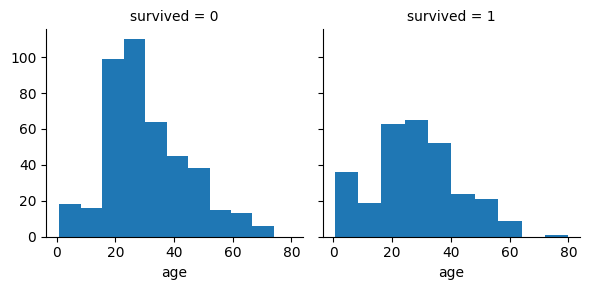

In [40]:
## 시각화 진행
import matplotlib.pyplot as plt # matplotlib은 유명 시각화 패키지

g1 = sns.FacetGrid(df, col='survived')
g1.map(plt.hist,'age')

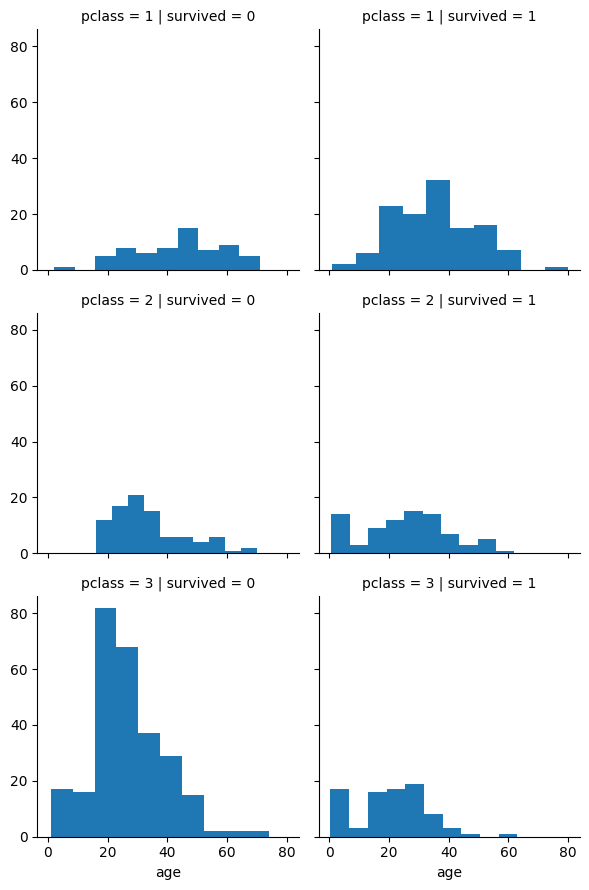

In [39]:
g2 = sns.FacetGrid(df, col='survived', row='pclass') # 열 기준으로 survived=0, survived=1 / 행 기준으로 pclas=1, pclass=2, pclass=3
g2.map(plt.hist,'age')

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a 

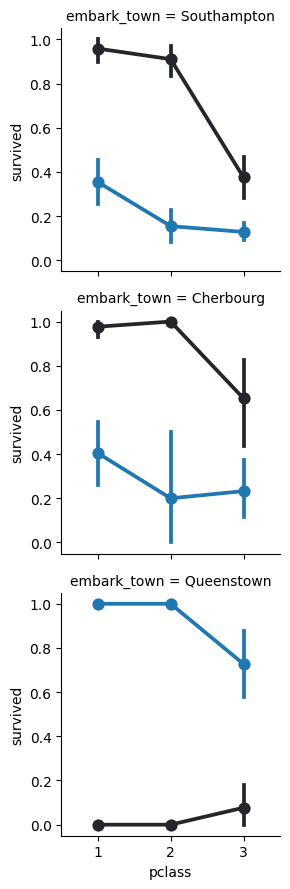

In [38]:
g4 = sns.FacetGrid(df, row='embark_town')
g4.map(sns.pointplot,'pclass','survived','sex')

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a 

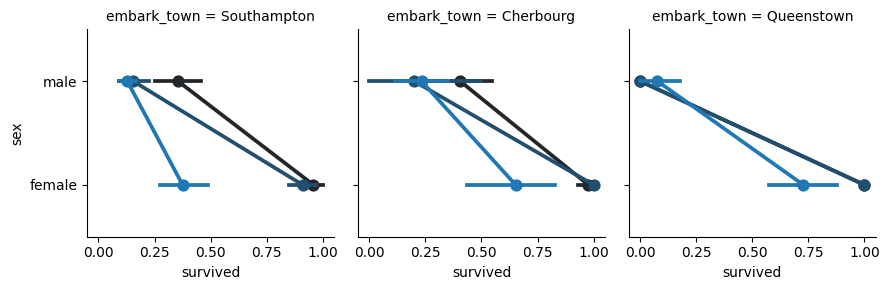

In [41]:
g6 = sns.FacetGrid(df, col='embark_town')
g6.map(sns.pointplot, 'survived','sex','pclass')

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a 

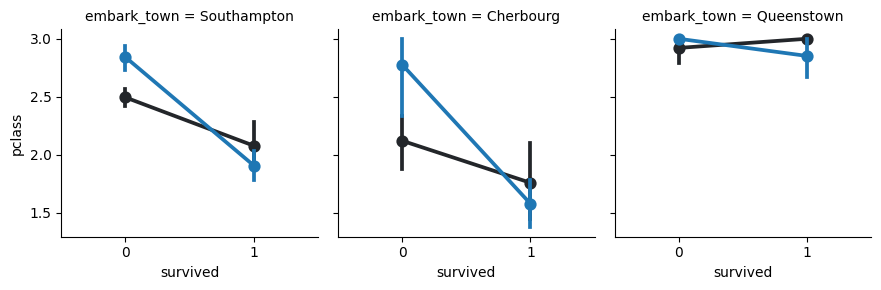

In [43]:
g6 = sns.FacetGrid(df, col='embark_town')
g6.map(sns.pointplot, 'survived','pclass','sex')

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a 

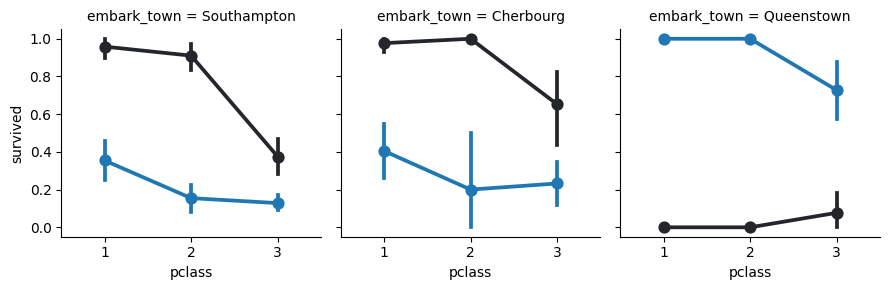

In [44]:
g6 = sns.FacetGrid(df, col='embark_town')
g6.map(sns.pointplot, 'pclass','survived','sex')

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


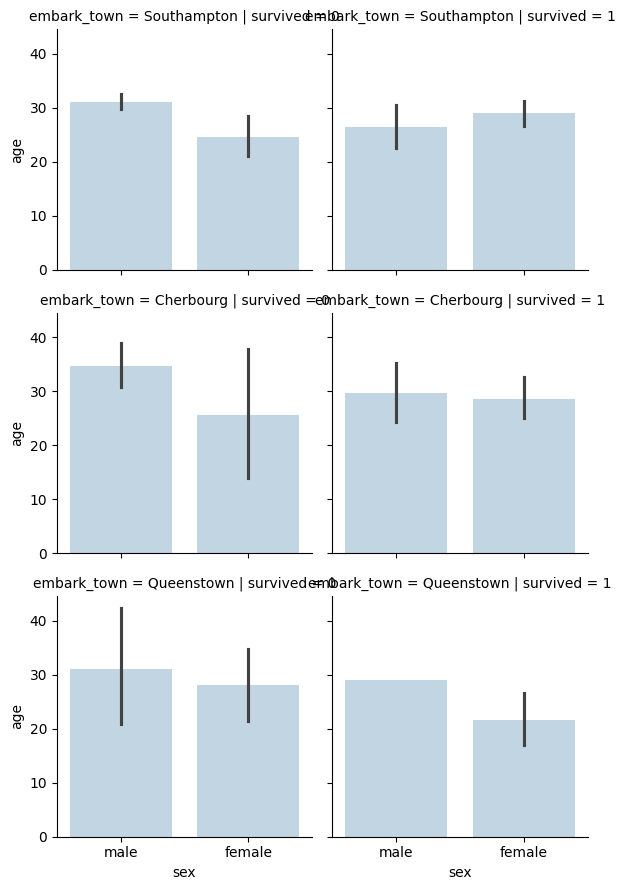

In [45]:
g5 =sns.FacetGrid(df, col='survived',row='embark_town')
g5.map(sns.barplot,'sex','age',alpha=0.3)
g5.add_legend() #범례설정